# Tennessee Valley cold front, 18–19 October 2025

ERA5 case study for north Alabama and southern Middle Tennessee. A cold front crossed the Valley on 19 October, with damaging-wind potential ahead of the boundary. Madison, AL is marked at 34.81°N, 86.73°W.

Data are the analysis-ready ERA5 store on Google Cloud, `gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3`, at 0.25° and hourly. Anonymous access, no Copernicus account. The domain is 32–37°N, 90–84°W. Run top to bottom in Colab. Subset before any `.load()`.

**Result.** No front at 06 UTC 18 October. On 19 October, 850 hPa cooling of about 8–9 K in 6 hours arrives from the northwest between 12 and 18 UTC. At 18 UTC that cooling sits on cold advection, frontogenesis, a mixing-ratio drop, and a southwest-to-northwest wind shift. The Madison sounding and a northwest–southeast section both put the cold air below about 700 hPa, with a dry slot above. Public sounding archives did not return a KHSV profile for these hours, so the balloon comparison is the limit of the notebook.


In [ ]:
# Colab setup. Skip the pip line if packages are already present.
%pip install -q metpy cartopy gcsfs zarr xarray matplotlib


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import SkewT
from metpy.interpolate import cross_section

import cartopy.crs as ccrs
import cartopy.feature as cfeature

STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
CASE_TIME = "2025-10-18T06:00"
FALLBACK_TIME = "2024-04-02T12:00"
LON_WEST, LON_EAST = -90.0, -84.0
LEVELS = [850, 500, 1000]
MADISON = dict(lat=34.81, lon=-86.73, name="Madison")


## Open the store

`chunks=None` keeps the file chunks. `token='anon'` is required. Nothing is read until `.load()`.


In [ ]:
ds = xr.open_zarr(
    STORE,
    chunks=None,
    storage_options={"token": "anon"},
)
needed = ["temperature", "u_component_of_wind", "v_component_of_wind",
          "geopotential", "mean_sea_level_pressure", "specific_humidity"]
print("variables present:", all(v in ds for v in needed))
print("valid_time_start:", ds.attrs.get("valid_time_start"))
print("valid_time_stop:", ds.attrs.get("valid_time_stop"))
print("latitude sample:", float(ds.latitude[0]), "...", float(ds.latitude[-1]))
print("longitude sample:", float(ds.longitude[0]), "...", float(ds.longitude[-1]))


In [ ]:
def to_store_lon(lon):
    """ERA5 ARCO longitudes are 0 to 360."""
    return lon % 360

def lat_slice_for(dataset):
    # slice must follow coordinate order
    if float(dataset.latitude[0]) > float(dataset.latitude[-1]):
        return slice(37.0, 32.0)
    return slice(32.0, 37.0)

valid_stop = np.datetime64(ds.attrs.get("valid_time_stop", "2022-12-31"))
case_time = np.datetime64(CASE_TIME)
if case_time > valid_stop:
    print(f"{CASE_TIME} is after valid_time_stop ({valid_stop}). Using {FALLBACK_TIME}.")
    case_time = np.datetime64(FALLBACK_TIME)
else:
    print(f"Using case time {case_time}.")

lon_slice = slice(to_store_lon(LON_WEST), to_store_lon(LON_EAST))
sub = ds[needed].sel(
    time=case_time,
    latitude=lat_slice_for(ds),
    longitude=lon_slice,
    level=LEVELS,
)
mslp = ds["mean_sea_level_pressure"].sel(
    time=case_time,
    latitude=lat_slice_for(ds),
    longitude=lon_slice,
)

sub = sub.load()
mslp = mslp.load()
sub


## 06 UTC 18 October: the null case

850 hPa potential temperature, Petterssen frontogenesis in K (100 km)⁻¹ (3 h)⁻¹, wind, and mean sea level pressure. This hour is before the frontal window.


In [ ]:
g = 9.80665

t850 = sub["temperature"].sel(level=850).values * units.kelvin
u850 = sub["u_component_of_wind"].sel(level=850).values * units("m/s")
v850 = sub["v_component_of_wind"].sel(level=850).values * units("m/s")

# Grid deltas use the store longitudes in the same order as the array.
dx, dy = mpcalc.lat_lon_grid_deltas(sub.longitude.values, sub.latitude.values)

theta850 = mpcalc.potential_temperature(850 * units.hPa, t850)
wspd850 = mpcalc.wind_speed(u850, v850)
fronto = mpcalc.frontogenesis(theta850, u850, v850, dx, dy)
fronto_plot = fronto * (1000 * 100 * 3600 * 3)  # K / 100 km / 3 h

# 1000 hPa is below ground on the Cumberland Plateau; thickness is a synoptic proxy.
z500 = sub["geopotential"].sel(level=500).values / g
z1000 = sub["geopotential"].sel(level=1000).values / g
thickness = (z500 - z1000) * units.meter

mslp_hpa = mslp.values / 100.0
lats = sub.latitude.values
lons = ((sub.longitude.values + 180) % 360) - 180  # -180..180 for Cartopy

print("850 theta range K:", float(theta850.min().m), float(theta850.max().m))
print("frontogenesis range:", float(fronto_plot.min().m), float(fronto_plot.max().m))
print("thickness range m:", float(thickness.min().m), float(thickness.max().m))


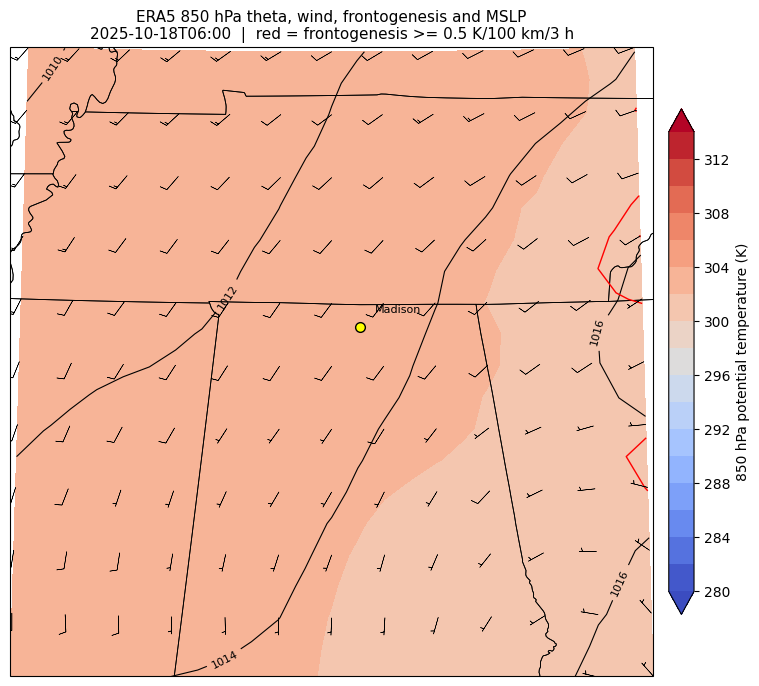

In [6]:
pc = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.LambertConformal(
    central_longitude=-87, central_latitude=35, standard_parallels=(33, 36)
))
ax.set_extent([LON_WEST, LON_EAST, 32, 37], crs=pc)

ax.add_feature(cfeature.STATES, linewidth=0.6)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

lon2d, lat2d = np.meshgrid(lons, lats)

cf = ax.contourf(
    lon2d, lat2d, np.asarray(theta850.m),
    levels=np.arange(280, 316, 2), cmap="coolwarm", transform=pc, extend="both",
)
cbar = fig.colorbar(cf, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label("850 hPa potential temperature (K)")

cs = ax.contour(
    lon2d, lat2d, mslp_hpa, levels=np.arange(990, 1032, 2),
    colors="k", linewidths=0.8, transform=pc,
)
ax.clabel(cs, fmt="%d", fontsize=8)

fpos = np.asarray(fronto_plot.m)
ax.contour(lon2d, lat2d, fpos, levels=[0.5, 1, 2, 3, 4], colors="red", linewidths=1.0, transform=pc)

step = 2
ax.barbs(
    lon2d[::step, ::step], lat2d[::step, ::step],
    np.asarray(u850.m)[::step, ::step], np.asarray(v850.m)[::step, ::step],
    length=5, linewidth=0.4, transform=pc, zorder=3,
)

ax.plot(MADISON["lon"], MADISON["lat"], marker="o", color="yellow",
        markeredgecolor="k", markersize=7, transform=pc, zorder=4)
ax.text(MADISON["lon"] + 0.15, MADISON["lat"] + 0.12, MADISON["name"],
        transform=pc, fontsize=8)

ax.set_title(
    f"ERA5 850 hPa theta, wind, frontogenesis and MSLP\n{case_time}  |  red = frontogenesis >= 0.5 K/100 km/3 h",
    fontsize=11,
)
fig.subplots_adjust(top=0.90)
plt.show()


### 06 UTC 18 October

The θ gradient and the frontogenesis do not line up with an MSLP trough, because there is no trough in the window.

Pressure is a weak northwest-to-east gradient: about 1010 hPa in the northwest corner, 1012–1014 hPa through the Valley, and 1016 hPa on the eastern edge. Madison sits between 1012 and 1014 hPa in a nearly flat field. Potential temperature is broad and warm, mostly 300–304 K, with southwest to west wind. The only θ gradient and the only frontogenesis are a short segment on the eastern border. They mark the edge of the plot, not a front crossing the Valley.


## Moisture at the same hour

A front with no moisture gradient is only a temperature boundary. Mixing ratio is \(w = q/(1-q)\).


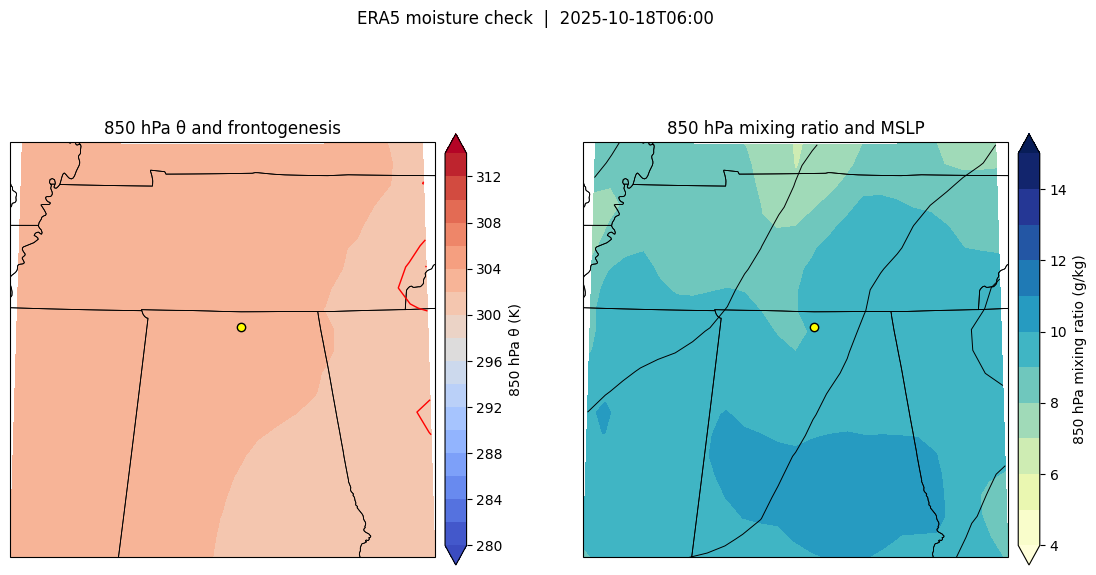

In [7]:
q850 = sub["specific_humidity"].sel(level=850).values * units("kg/kg")
w850 = mpcalc.mixing_ratio_from_specific_humidity(q850)
w850_gkg = w850.to("g/kg")

pc = ccrs.PlateCarree()
proj = ccrs.LambertConformal(
    central_longitude=-87, central_latitude=35, standard_parallels=(33, 36)
)
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7), subplot_kw={"projection": proj}
)

def base_map(ax):
    ax.set_extent([LON_WEST, LON_EAST, 32, 37], crs=pc)
    ax.add_feature(cfeature.STATES, linewidth=0.6)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.plot(
        MADISON["lon"], MADISON["lat"], marker="o", color="yellow",
        markeredgecolor="k", markersize=6, transform=pc, zorder=4,
    )

# Left: 850 hPa theta, same levels as the first map
base_map(axes[0])
cf0 = axes[0].contourf(
    lon2d, lat2d, np.asarray(theta850.m),
    levels=np.arange(280, 316, 2), cmap="coolwarm", transform=pc, extend="both",
)
fig.colorbar(cf0, ax=axes[0], pad=0.02, shrink=0.8, label="850 hPa θ (K)")
axes[0].contour(
    lon2d, lat2d, np.asarray(fronto_plot.m),
    levels=[0.5, 1, 2, 3, 4], colors="red", linewidths=1.0, transform=pc,
)
axes[0].set_title("850 hPa θ and frontogenesis")

# Right: 850 hPa mixing ratio. A real front should have a gradient here too.
base_map(axes[1])
cf1 = axes[1].contourf(
    lon2d, lat2d, np.asarray(w850_gkg.m),
    levels=np.arange(4, 16, 1), cmap="YlGnBu", transform=pc, extend="both",
)
fig.colorbar(cf1, ax=axes[1], pad=0.02, shrink=0.8, label="850 hPa mixing ratio (g/kg)")
axes[1].contour(
    lon2d, lat2d, mslp_hpa, levels=np.arange(990, 1032, 2),
    colors="k", linewidths=0.7, transform=pc,
)
axes[1].set_title("850 hPa mixing ratio and MSLP")

fig.suptitle(f"ERA5 moisture check  |  {case_time}", fontsize=12)
fig.subplots_adjust(top=0.88, wspace=0.12)
plt.show()

print("850 mixing ratio range g/kg:", float(w850_gkg.min().m), float(w850_gkg.max().m))


### Moisture check, 06 UTC 18 October

The moisture field agrees with the temperature field. Mixing ratio stays in a narrow band, roughly 7–11 g/kg, with no packed drop on the eastern θ gradient. Madison is in warm, modestly moist air. The eastern feature fails the moisture test.


## Does the boundary strengthen on 19 October?

Successive 6-hour changes in 850 hPa θ. Cool colors are cooling.


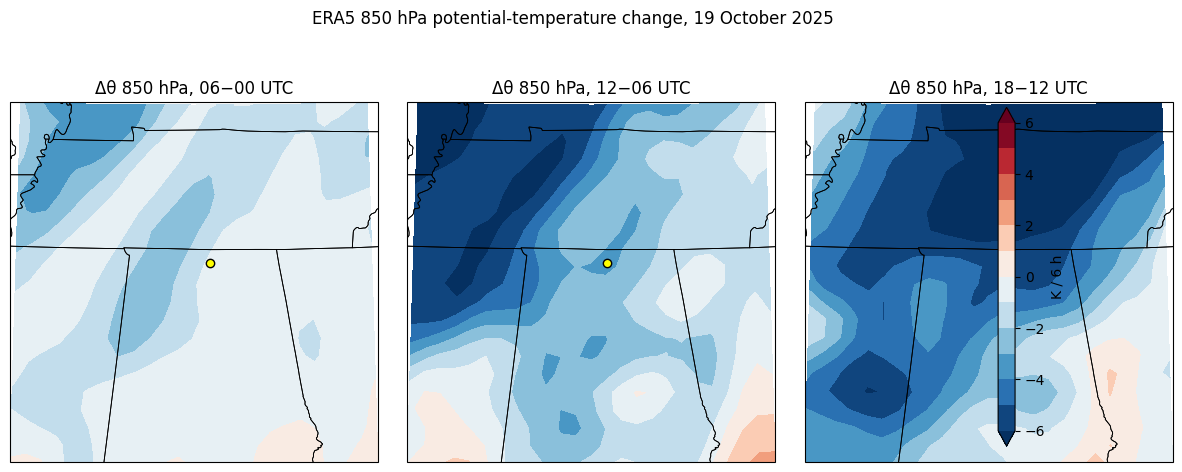

In [8]:
times = [
    "2025-10-19T00:00",
    "2025-10-19T06:00",
    "2025-10-19T12:00",
    "2025-10-19T18:00",
]
lat_sl = lat_slice_for(ds)
lon_sl = slice(to_store_lon(LON_WEST), to_store_lon(LON_EAST))

t_series = ds["temperature"].sel(
    time=times,
    level=850,
    latitude=lat_sl,
    longitude=lon_sl,
).load()

theta = mpcalc.potential_temperature(
    850 * units.hPa,
    t_series.values * units.kelvin,
)
theta_k = np.asarray(theta.m)  # (time, lat, lon)

lats_t = t_series.latitude.values
lons_t = ((t_series.longitude.values + 180) % 360) - 180
lon2d_t, lat2d_t = np.meshgrid(lons_t, lats_t)

# Successive differences: 06-00, 12-06, 18-12
dtheta = np.diff(theta_k, axis=0)
pair_labels = ["06−00 UTC", "12−06 UTC", "18−12 UTC"]

pc = ccrs.PlateCarree()
proj = ccrs.LambertConformal(
    central_longitude=-87, central_latitude=35, standard_parallels=(33, 36)
)
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), subplot_kw={"projection": proj})
dlev = np.arange(-6, 6.1, 1)

for ax, dth, label in zip(axes, dtheta, pair_labels):
    ax.set_extent([LON_WEST, LON_EAST, 32, 37], crs=pc)
    ax.add_feature(cfeature.STATES, linewidth=0.6)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    cf = ax.contourf(
        lon2d_t, lat2d_t, dth, levels=dlev, cmap="RdBu_r",
        transform=pc, extend="both",
    )
    ax.plot(
        MADISON["lon"], MADISON["lat"], marker="o", color="yellow",
        markeredgecolor="k", markersize=6, transform=pc, zorder=4,
    )
    ax.set_title(f"Δθ 850 hPa, {label}")

fig.colorbar(cf, ax=axes, pad=0.02, shrink=0.8, label="K / 6 h")
fig.suptitle("ERA5 850 hPa potential-temperature change, 19 October 2025", fontsize=12)
fig.subplots_adjust(top=0.86, wspace=0.08)
plt.show()

for label, dth in zip(pair_labels, dtheta):
    print(f"{label}: min {dth.min():.2f} K, max {dth.max():.2f} K")


### Potential-temperature change, 19 October

The boundary strengthens, and it arrives from the northwest.

From 00 to 06 UTC the cooling is weak, at most about −4 K, and Madison is still in the near-zero band. From 06 to 12 UTC a coherent cold band drops out of the northwest, with a minimum of −7.6 K in 6 hours. Madison is on the eastern edge of that band. From 12 to 18 UTC the signal deepens to −8.8 K and covers the northern half of the domain, including Madison. A little warming remains only in the southeast corner. That is a cold-air push, not a uniform diurnal cool-down.


## Advection and the wind shift

Negative values are cold advection, plotted in K per 3 hours. Wind barbs go on the mixing-ratio panel.


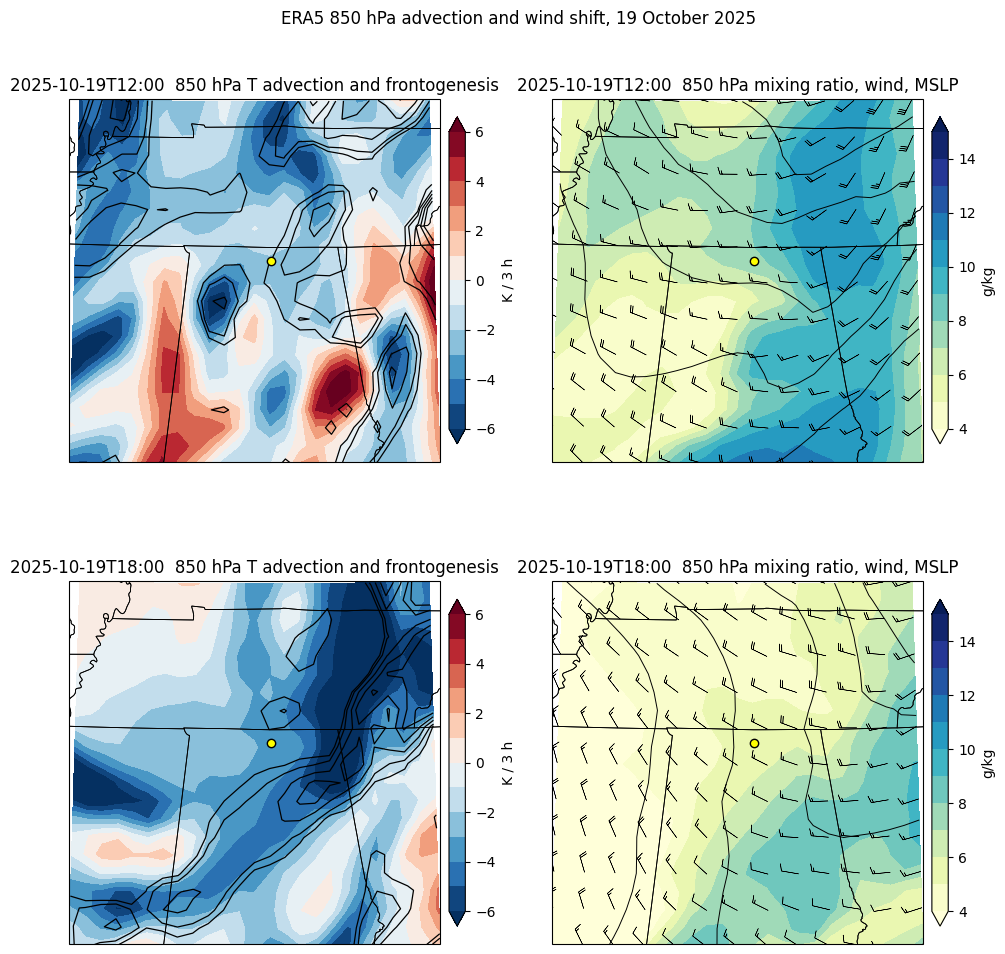

In [9]:
check_times = ["2025-10-19T12:00", "2025-10-19T18:00"]
lat_sl = lat_slice_for(ds)
lon_sl = slice(to_store_lon(LON_WEST), to_store_lon(LON_EAST))

temp = ds["temperature"].sel(time=check_times, level=850, latitude=lat_sl, longitude=lon_sl).load()
u = ds["u_component_of_wind"].sel(time=check_times, level=850, latitude=lat_sl, longitude=lon_sl).load()
v = ds["v_component_of_wind"].sel(time=check_times, level=850, latitude=lat_sl, longitude=lon_sl).load()
q = ds["specific_humidity"].sel(time=check_times, level=850, latitude=lat_sl, longitude=lon_sl).load()
mslp_chk = ds["mean_sea_level_pressure"].sel(time=check_times, latitude=lat_sl, longitude=lon_sl).load()

lats_c = temp.latitude.values
lons_c = ((temp.longitude.values + 180) % 360) - 180
lon2d_c, lat2d_c = np.meshgrid(lons_c, lats_c)
dx_c, dy_c = mpcalc.lat_lon_grid_deltas(temp.longitude.values, temp.latitude.values)

pc = ccrs.PlateCarree()
proj = ccrs.LambertConformal(
    central_longitude=-87, central_latitude=35, standard_parallels=(33, 36)
)
fig, axes = plt.subplots(2, 2, figsize=(12, 11), subplot_kw={"projection": proj})

def base_map(ax):
    ax.set_extent([LON_WEST, LON_EAST, 32, 37], crs=pc)
    ax.add_feature(cfeature.STATES, linewidth=0.6)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.plot(
        MADISON["lon"], MADISON["lat"], marker="o", color="yellow",
        markeredgecolor="k", markersize=6, transform=pc, zorder=4,
    )

step = 2
for i, when in enumerate(check_times):
    t_i = temp.sel(time=when).values * units.kelvin
    u_i = u.sel(time=when).values * units("m/s")
    v_i = v.sel(time=when).values * units("m/s")
    q_i = q.sel(time=when).values * units("kg/kg")
    mslp_i = mslp_chk.sel(time=when).values / 100.0

    theta_i = mpcalc.potential_temperature(850 * units.hPa, t_i)
    fronto_i = mpcalc.frontogenesis(theta_i, u_i, v_i, dx_c, dy_c) * (1000 * 100 * 3600 * 3)
    # MetPy advection is already -v·∇T. Negative = cold advection.
    tadv_i = mpcalc.advection(t_i, u_i, v_i, dx=dx_c, dy=dy_c).to("K/hour") * 3
    w_i = mpcalc.mixing_ratio_from_specific_humidity(q_i).to("g/kg")

    base_map(axes[i, 0])
    cf0 = axes[i, 0].contourf(
        lon2d_c, lat2d_c, np.asarray(tadv_i.m),
        levels=np.arange(-6, 6.1, 1), cmap="RdBu_r", transform=pc, extend="both",
    )
    axes[i, 0].contour(
        lon2d_c, lat2d_c, np.asarray(fronto_i.m),
        levels=[0.5, 1, 2, 3, 4], colors="k", linewidths=0.9, transform=pc,
    )
    axes[i, 0].set_title(f"{when}  850 hPa T advection and frontogenesis")
    fig.colorbar(cf0, ax=axes[i, 0], pad=0.02, shrink=0.8, label="K / 3 h")

    base_map(axes[i, 1])
    cf1 = axes[i, 1].contourf(
        lon2d_c, lat2d_c, np.asarray(w_i.m),
        levels=np.arange(4, 16, 1), cmap="YlGnBu", transform=pc, extend="both",
    )
    axes[i, 1].contour(
        lon2d_c, lat2d_c, mslp_i, levels=np.arange(990, 1032, 2),
        colors="k", linewidths=0.7, transform=pc,
    )
    axes[i, 1].barbs(
        lon2d_c[::step, ::step], lat2d_c[::step, ::step],
        np.asarray(u_i.m)[::step, ::step], np.asarray(v_i.m)[::step, ::step],
        length=5, linewidth=0.4, transform=pc, zorder=3,
    )
    axes[i, 1].set_title(f"{when}  850 hPa mixing ratio, wind, MSLP")
    fig.colorbar(cf1, ax=axes[i, 1], pad=0.02, shrink=0.8, label="g/kg")

    print(
        when,
        "T adv", f"{float(tadv_i.min().m):.1f}–{float(tadv_i.max().m):.1f} K/3h",
        "w", f"{float(w_i.min().m):.1f}–{float(w_i.max().m):.1f} g/kg",
        "frontogenesis", f"{float(fronto_i.min().m):.2f}–{float(fronto_i.max().m):.2f}",
    )

fig.suptitle("ERA5 850 hPa advection and wind shift, 19 October 2025", fontsize=12)
fig.subplots_adjust(top=0.92, hspace=0.18, wspace=0.08)
plt.show()


### 12 and 18 UTC 19 October

The cooling is advective, and the wind shift is real. At 18 UTC this is a front. At 12 UTC it is only arriving.

At 12 UTC cold advection is broken: a band of roughly −2 to −4 K per 3 hours runs from the northwest toward Madison, while warm advection of several K per 3 hours is still in place over eastern Alabama. Mixing ratio is still 8–11 g/kg, and the barbs are mostly southwest to west.

By 18 UTC cold advection covers the northern and western half of the domain, locally −6 to about −12 K per 3 hours, on the same northwest-to-southeast corridor as the −8 K potential-temperature fall. Frontogenesis peaks near 9 K per 100 km per 3 hours. Mixing ratio falls to about 4–8 g/kg, and the barbs veer to west-northwest behind the gradient.

The 12 UTC advection field is noisy, which is what a 0.25° gradient looks like before the front consolidates. The 18 UTC advection, up to −12 K per 3 hours, is stronger than the 6-hour Δθ. Vertical motion and mixing cancel part of the horizontal term. The horizontal term is the driver, not the whole budget.


## Madison soundings

All 37 pressure levels at the nearest ERA5 grid point. Dewpoint is from specific humidity.


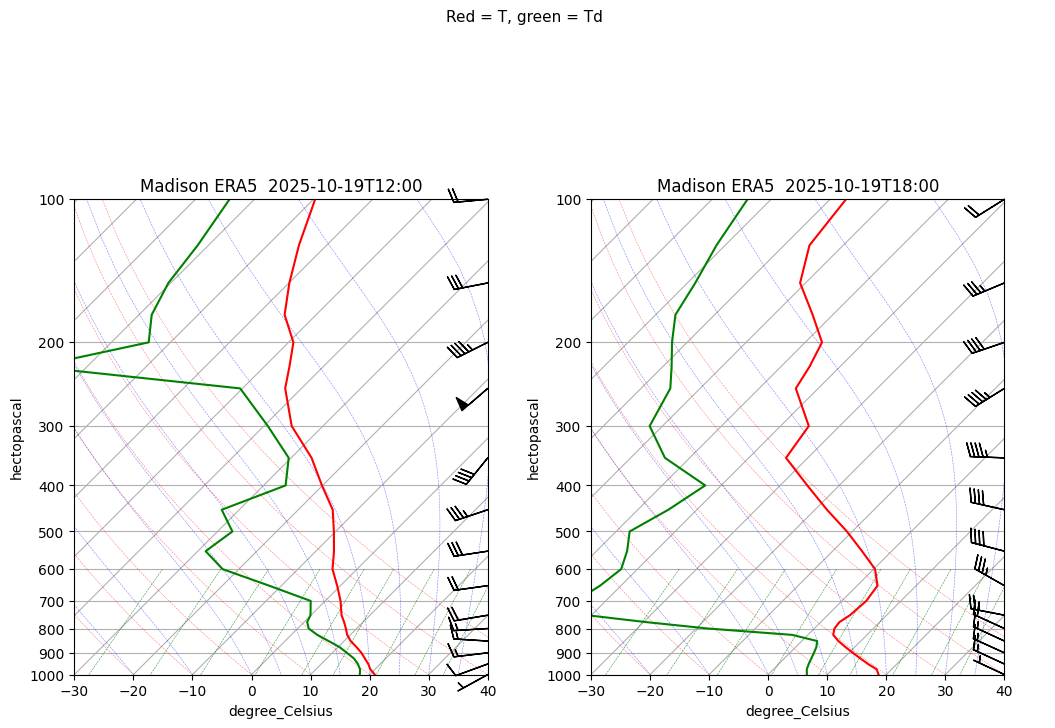

In [10]:
sounding_times = ["2025-10-19T12:00", "2025-10-19T18:00"]
pt = ds.sel(
    latitude=MADISON["lat"],
    longitude=to_store_lon(MADISON["lon"]),
    method="nearest",
)
print(
    "nearest grid point:",
    float(pt.latitude),
    float(((pt.longitude + 180) % 360) - 180),
)

prof = pt[["temperature", "specific_humidity", "u_component_of_wind", "v_component_of_wind"]].sel(
    time=sounding_times
).load()

# Skew-T wants pressure decreasing upward.
prof = prof.sortby("level", ascending=False)
p = prof.level.values * units.hPa

fig = plt.figure(figsize=(12, 9))
for i, when in enumerate(sounding_times):
    col = prof.sel(time=when)
    T = col["temperature"].values * units.kelvin
    q = col["specific_humidity"].values * units("kg/kg")
    Td = mpcalc.dewpoint_from_specific_humidity(p, q)
    u_snd = col["u_component_of_wind"].values * units("m/s")
    v_snd = col["v_component_of_wind"].values * units("m/s")

    skew = SkewT(fig, subplot=(1, 2, i + 1), rotation=45)
    skew.plot(p, T.to("degC"), "r", linewidth=1.5)
    skew.plot(p, Td.to("degC"), "g", linewidth=1.5)
    # Barbs every other level so 37 levels stay readable.
    skew.plot_barbs(p[::2], u_snd[::2], v_snd[::2])
    skew.plot_dry_adiabats(linewidth=0.4)
    skew.plot_moist_adiabats(linewidth=0.4)
    skew.plot_mixing_lines(linewidth=0.4)
    skew.ax.set_ylim(1000, 100)
    skew.ax.set_xlim(-30, 40)
    skew.ax.set_title(f"Madison ERA5  {when}")

fig.suptitle("Red = T, green = Td", fontsize=11)
fig.subplots_adjust(top=0.90, wspace=0.25)
plt.show()


### Soundings

The nearest point is 34.75°N, 86.75°W. The front passes Madison between 12 and 18 UTC as a shallow cold layer.

At 12 UTC the lower troposphere is still warm, about 20°C near 1000 hPa and about 10°C through 850–700 hPa. Dewpoint sits close to temperature below 900 hPa, then dries sharply above that. Winds are southwesterly to westerly.

By 18 UTC temperature falls to near 5°C from 850 hPa to near 650 hPa. That is a frontal inversion. Dewpoint collapses above 850 hPa, from around 5°C near the surface to below −30°C by 750 hPa. Low-level wind has veered toward the west and northwest. The passage is real, but it is confined mostly below 700 hPa.


## Cross section

The line runs from 36°N, 89°W to 33°N, 85°W at 18 UTC 19 October. It passes west of Madison, so the sounding is a point on the same front, not the same column. The dashed line is 700 hPa.


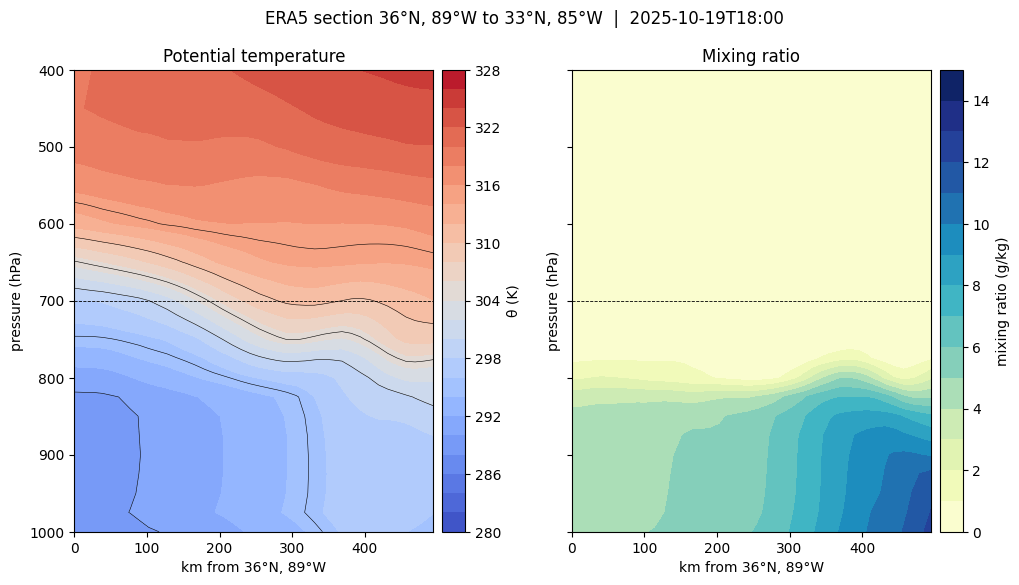

In [11]:
when = "2025-10-19T18:00"
start = (36.0, to_store_lon(-89.0))   # store longitude is 0-360
end = (33.0, to_store_lon(-85.0))

sec = ds[["temperature", "specific_humidity"]].sel(
    time=when,
    latitude=lat_slice_for(ds),
    longitude=slice(to_store_lon(-90.5), to_store_lon(-83.5)),
).load()
sec = sec.sortby("level", ascending=False)
sec = sec.metpy.assign_crs(grid_mapping_name="latitude_longitude", earth_radius=6371229.0)

cross = cross_section(sec, start, end, steps=40).set_coords(("latitude", "longitude"))
p_sec = cross.level.values * units.hPa
theta_sec = mpcalc.potential_temperature(p_sec[:, None], cross["temperature"].values * units.kelvin)
w_sec = mpcalc.mixing_ratio_from_specific_humidity(
    cross["specific_humidity"].values * units("kg/kg")
).to("g/kg")

# Distance along the section, in km, for the x-axis.
lat_km = np.asarray(cross.latitude.values, dtype=float)
lon_km = ((np.asarray(cross.longitude.values, dtype=float) + 180) % 360) - 180
lat0 = np.deg2rad(lat_km.mean())
step_km = np.hypot(np.diff(lat_km) * 111.0, np.diff(lon_km) * 111.0 * np.cos(lat0))
dist = np.concatenate([[0.0], np.cumsum(step_km)])

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
cf0 = axes[0].contourf(dist, cross.level, np.asarray(theta_sec.m), levels=np.arange(280, 330, 2), cmap="coolwarm")
axes[0].contour(dist, cross.level, np.asarray(theta_sec.m), levels=np.arange(290, 320, 5), colors="k", linewidths=0.4)
fig.colorbar(cf0, ax=axes[0], pad=0.02, label="θ (K)")
axes[0].set_title("Potential temperature")

cf1 = axes[1].contourf(dist, cross.level, np.asarray(w_sec.m), levels=np.arange(0, 16, 1), cmap="YlGnBu")
fig.colorbar(cf1, ax=axes[1], pad=0.02, label="mixing ratio (g/kg)")
axes[1].set_title("Mixing ratio")

for ax in axes:
    ax.set_ylim(1000, 400)
    ax.set_xlabel("km from 36°N, 89°W")
    ax.set_ylabel("pressure (hPa)")
    ax.axhline(700, color="k", linewidth=0.6, linestyle="--")

fig.suptitle(f"ERA5 section 36°N, 89°W to 33°N, 85°W  |  {when}", fontsize=12)
fig.subplots_adjust(top=0.88, wspace=0.15)
plt.show()


### Cross section, 18 UTC 19 October

The shallow cold air is valley-wide. The front slopes up from northwest to southeast, and the moist air is piled on the warm side.

The cold wedge sits below about 750 hPa from the northwest end through roughly 300 km. Isentropes there are nearly vertical below 800 hPa, then bend and slope upward toward the southeast. Southeast of about 350 km the cold layer is gone and θ below 800 hPa is several kelvin warmer.

Mixing ratio shows the same slope. The northwest end is dry below 800 hPa, about 4–6 g/kg, with almost nothing above 750 hPa. By 400 km the 8–12 g/kg air extends from the surface to about 800 hPa. The dry slot above 750 hPa runs the length of the section, the same feature as the dewpoint collapse on the 18 UTC Madison sounding.

Madison lies about 150–200 km along this line, and a little east of it. At that distance the section is inside the cold wedge and under the dry air. The depth is a property of the front, not of the grid point.


## Conclusion

ERA5 at 0.25° resolves a shallow, sloping cold-frontal passage on 19 October 2025.

- 06 UTC 18 October is the null case: no trough, no moisture gradient, and no front over the Valley.
- 850 hPa cooling of about 8–9 K in 6 hours arrives from the northwest between 12 and 18 UTC on the 19th.
- At 18 UTC that cooling sits on cold advection, frontogenesis, a mixing-ratio drop, and a wind shift from southwest to west-northwest.
- The Madison profile and the section both confine the cold air to below about 700 hPa, with a dry slot above.

Iowa State and Wyoming did not return a KHSV sounding for these hours, so the sharpness of the observed inversion is unresolved. ERA5 will be smoother than the balloon on a front this shallow.


## Citations

Hersbach and coauthors, 2020: The ERA5 global reanalysis, Quarterly Journal of the Royal Meteorological Society, 146, 1999–2049, doi:10.1002/qj.3803

May and coauthors, 2022: MetPy: A meteorological Python library for data analysis and visualization, Bulletin of the American Meteorological Society, 103, E2273–E2284, doi:10.1175/BAMS-D-21-0125.1

Bluestein, 1993, Synoptic-Dynamic Meteorology in Midlatitudes, Volume II